In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
dataframe = pd.read_csv('features_labels_train_seed_11.csv')
dataframe.head()
dataframe.info()
dataframe.describe()

<class 'pandas.DataFrame'>
RangeIndex: 97477 entries, 0 to 97476
Columns: 514 entries, Unnamed: 0 to label
dtypes: float64(512), int64(2)
memory usage: 382.3 MB


,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,503,504,505,506,507,508,509,510,511,label
count,97477.000000,97477.000000,97477.000000,97477.000000,97477.000000,97477.000000,97477.000000,97477.000000,97477.000000,97477.000000,...,97477.000000,97477.000000,97477.000000,97477.000000,97477.000000,97477.000000,97477.000000,97477.000000,97477.000000,97477.000000
mean,48738.000000,0.681872,0.852046,0.447820,2.224551,0.402598,0.151762,0.788433,0.949997,1.450155,...,1.293177,0.069754,1.366083,0.856232,0.751028,0.793370,0.943561,1.014040,1.953876,1.680386
std,28139.330432,0.534972,0.469023,0.377556,0.650455,0.390712,0.248600,0.378322,0.579631,0.564793,...,0.648417,0.127808,0.750498,0.430904,0.546999,0.445132,0.752507,0.490833,0.820517,1.359720
min,0.000000,0.000000,0.000000,0.000000,0.065531,0.000000,0.000000,0.000000,0.000000,0.006802,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24369.000000,0.251920,0.496273,0.144303,1.773770,0.123625,0.001275,0.516438,0.518277,1.039677,...,0.808286,0.000916,0.823064,0.537727,0.336351,0.466648,0.356883,0.655309,1.372844,0.000000
50%,48738.000000,0.572828,0.817914,0.366651,2.215980,0.297666,0.041144,0.761701,0.884740,1.408885,...,1.232653,0.021107,1.260078,0.790383,0.650470,0.716623,0.769292,0.970395,1.943406,2.000000
75%,73107.000000,0.999981,1.158221,0.663484,2.655075,0.558299,0.191789,1.022538,1.301202,1.815442,...,1.716320,0.080656,1.781113,1.109096,1.048951,1.041308,1.353470,1.319696,2.512234,3.000000
max,97476.000000,4.150271,3.961256,3.236801,5.985311,4.308750,2.836559,3.438795,5.015739,4.157586,...,5.151071,2.531129,5.641161,3.500565,4.883369,3.861810,6.236914,4.224940,5.900908,3.000000


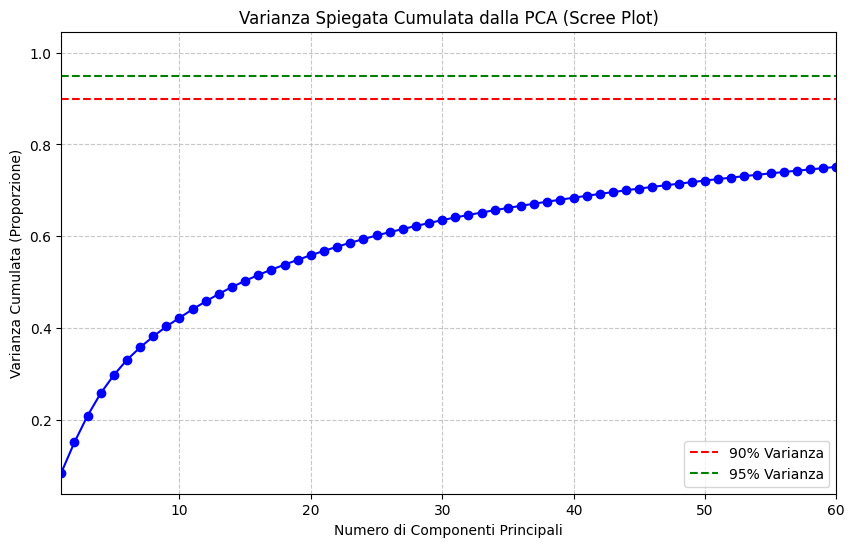

In [ ]:
# 1. Standardizzazione
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(dataframe)

# 2. Inizializza la PCA SENZA specificare il numero di componenti.
# In questo modo calcolerà tutte le 512 componenti (o min(n_samples, n_features)).
pca = PCA()
pca.fit(X_train_scaled)

# 3. Estrai la proporzione di varianza spiegata da ogni singola componente
# e calcola la somma cumulativa
varianza_singola = pca.explained_variance_ratio_
varianza_cumulata = np.cumsum(varianza_singola)

# 4. Creazione del Grafico (Scree Plot)
plt.figure(figsize=(10, 6))

# Plotta la curva della varianza cumulata
plt.plot(range(1, len(varianza_cumulata) + 1), varianza_cumulata, marker='o', linestyle='-', color='b')
plt.xlim(1, 60)

# Aggiungi linee di riferimento (es. per il 90% e il 95% della varianza)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Varianza')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Varianza')

# Estetica del grafico
plt.title('Varianza Spiegata Cumulata dalla PCA (Scree Plot)')
plt.xlabel('Numero di Componenti Principali')
plt.ylabel('Varianza Cumulata (Proporzione)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

In [6]:
PCA_32 = PCA(n_components=32)
X_train_pca_32 = PCA_32.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 32 componenti: {PCA_32.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 32 componenti: 0.6464
